In [26]:
import sys
import os

# Obtener el directorio padre (ruta base del proyecto)
base_path = os.path.abspath('..')
if base_path not in sys.path:
    sys.path.append(base_path)

import paths
import pandas as pd
import matplotlib.pyplot as plt
import modos_color
import numpy as np

## Rutas del proyecto
data_dir = paths.data_dir()
avance3_base = paths.fase3_segmentacion_dir()

# imagenes seleccionadas para cambio de color
sel_img_path = os.path.join(avance3_base, "imagenes_prueba.csv")
sel_img_df = pd.read_csv(sel_img_path)

Leemos las imagenes en RGB y las guardamos en un diccionario por canal y por dificultad. Luego, para cada modo de color (CMY, CMYK, HSI), convertimos las imágenes RGB a ese modo y las guardamos en el diccionario correspondiente.

In [27]:
imagenes_rgb = {}
for idx, row in sel_img_df.iterrows():
    img_name = row["ruta_imagen"]
    img_num = row["dificultad"]
    img_path = os.path.join(data_dir, img_name)
    
    # Leer la imagen
    R, G, B = modos_color.read_image_by_channels(img_path)
    imagenes_rgb[img_num] = (R, G, B)

In [28]:
imagenes_cmy = {}
imagenes_cmyk = {}
imagenes_hsi = {}

# Para cada imagen rgb, convertir a los otros modos de color y guardar en los diccionarios correspondientes
# la clave es la dificultad de la imagen, y el valor es una tupla con los canales correspondientes a cada modo de color

for img_num, (R, G, B) in imagenes_rgb.items():
    # Convertir a CMY
    C, M, Y = modos_color.rgb_a_cmy(R, G, B)
    imagenes_cmy[img_num] = (C, M, Y)
    
    # Convertir a CMYK
    C_k, M_k, Y_k, K_k = modos_color.rgb_a_cmyk(R, G, B)
    imagenes_cmyk[img_num] = (C_k, M_k, Y_k, K_k)
    
    # Convertir a HSI
    H, S, I = modos_color.rgb_a_hsi(R, G, B)
    imagenes_hsi[img_num] = (H, S, I)

Para el analisis, se generaran histogramas de cada canal para cada modo de color, y se compararan visualmente para identificar diferencias significativas entre los modos. Ademas, se calcularan estadisticas descriptivas (media, mediana, desviacion estandar) para cada canal en cada modo de color, y se compararan entre modos para identificar patrones o tendencias.

In [29]:
def distribucion_histograma(channels, names_channels, normalize=True, tipo="RGB"):
    '''Muestra en un solo gráfico la distribución de cada canal de color
    independientemente del modo de color al que correspondan'''

    if tipo == "RGB":
        colors = ['red', 'green', 'blue']
    elif tipo == "CMY":
        colors = ['cyan', 'magenta', 'yellow']
    elif tipo == "CMYK":
        colors = ['cyan', 'magenta', 'yellow', 'black']
    elif tipo == "HSI":
        colors = ['orange', 'purple', 'gray']

    for channel, name in zip(channels, names_channels):
        data = channel.flatten()
        # Normalizar al rango [0, 1] si es necesario (ej. H en grados)
        if data.max() > 1.0:
            data = data / data.max()

        plt.hist(data, bins=256, alpha=0.5, label=name, density=normalize, color=colors[names_channels.index(name)])

    plt.title("Distribución de los histogramas de los canales de color")
    plt.xlabel("Intensidad de color")
    plt.ylabel("Frecuencia")
    plt.legend(names_channels)
    plt.xlim([0, 1])
    return plt

### Pruebas en imagenes independientes

Para la imagen con dificultad 1

Mostrando histogramas para la imagen con dificultad 1


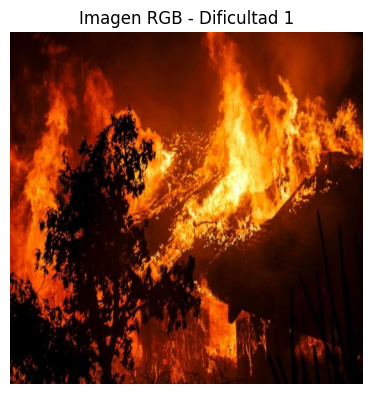

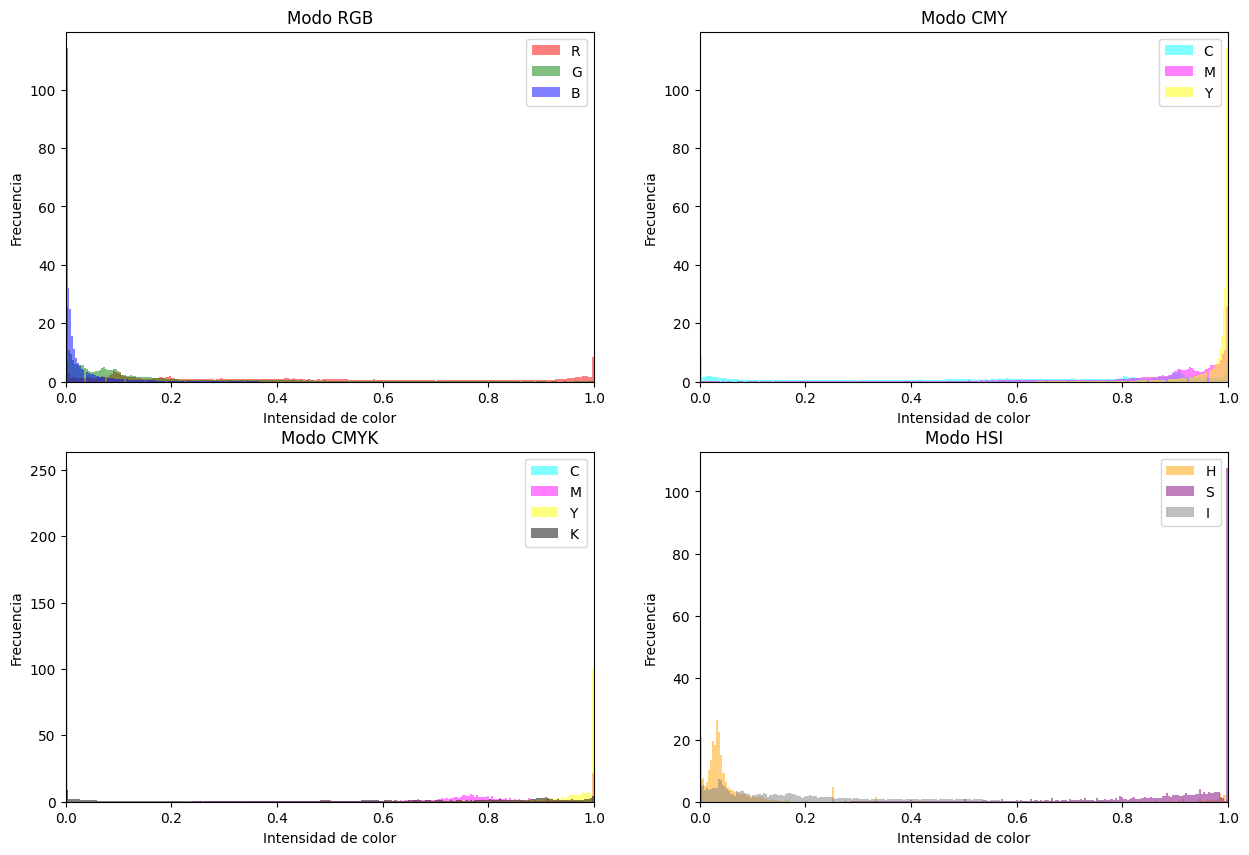

In [44]:
# Para la imagen 1 en todos los modos de color, mostrar la distribución de los histogramas de cada canal de color
img_num = 1

R, G, B = imagenes_rgb[img_num]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(np.stack((R, G, B), axis=-1))
plt.title(f"Imagen RGB - Dificultad {img_num}")
plt.axis('off')

channels_rgb = imagenes_rgb[img_num]
channels_cmy = imagenes_cmy[img_num]
channels_cmyk = imagenes_cmyk[img_num]
channels_hsi = imagenes_hsi[img_num]

print(f"Mostrando histogramas para la imagen con dificultad {img_num}")

# Generamos una figura con 4 subplots para mostrar los histogramas de cada modo de color
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
distribucion_histograma(channels_rgb, ["R", "G", "B"], tipo="RGB")
plt.title("Modo RGB")
plt.subplot(2, 2, 2)
distribucion_histograma(channels_cmy, ["C", "M", "Y"], tipo="CMY")
plt.title("Modo CMY")
plt.subplot(2, 2, 3)
distribucion_histograma(channels_cmyk, ["C", "M", "Y", "K"], tipo="CMYK")
plt.title("Modo CMYK")
plt.subplot(2, 2, 4)
distribucion_histograma(channels_hsi, ["H", "S", "I"], tipo="HSI")
plt.title("Modo HSI")
plt.show()

Para imagen con dificultad 7

Mostrando histogramas para la imagen con dificultad 7


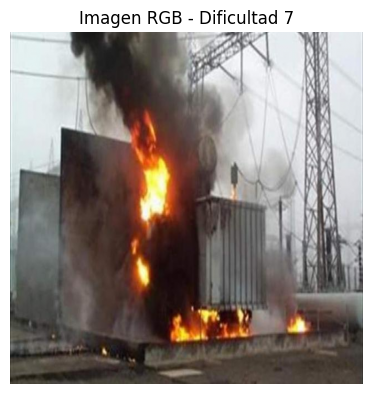

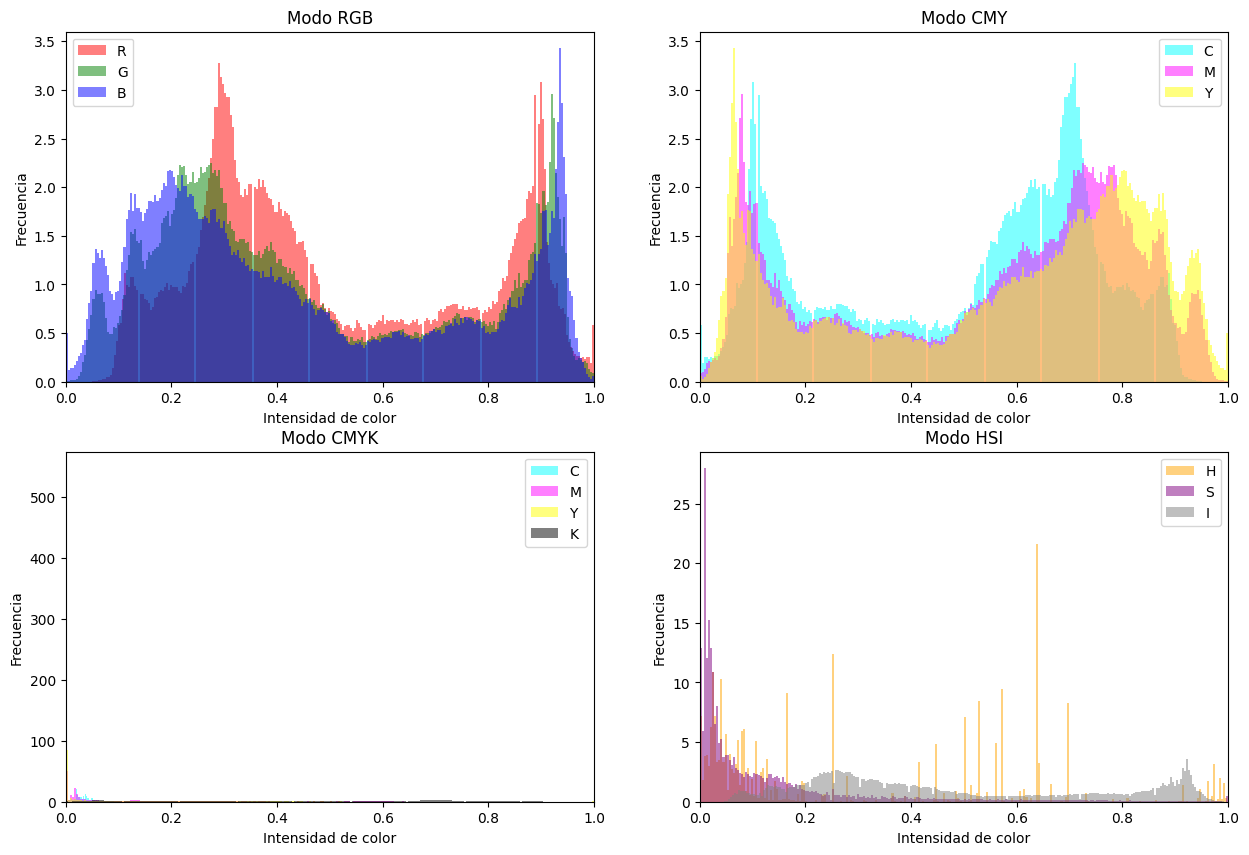

In [45]:
# Para la imagen 1 en todos los modos de color, mostrar la distribución de los histogramas de cada canal de color
img_num = 7

R, G, B = imagenes_rgb[img_num]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(np.stack((R, G, B), axis=-1))
plt.title(f"Imagen RGB - Dificultad {img_num}")
plt.axis('off')

channels_rgb = imagenes_rgb[img_num]
channels_cmy = imagenes_cmy[img_num]
channels_cmyk = imagenes_cmyk[img_num]
channels_hsi = imagenes_hsi[img_num]

print(f"Mostrando histogramas para la imagen con dificultad {img_num}")

# Generamos una figura con 4 subplots para mostrar los histogramas de cada modo de color
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
distribucion_histograma(channels_rgb, ["R", "G", "B"], tipo="RGB")
plt.title("Modo RGB")
plt.subplot(2, 2, 2)
distribucion_histograma(channels_cmy, ["C", "M", "Y"], tipo="CMY")
plt.title("Modo CMY")
plt.subplot(2, 2, 3)
distribucion_histograma(channels_cmyk, ["C", "M", "Y", "K"], tipo="CMYK")
plt.title("Modo CMYK")
plt.subplot(2, 2, 4)
distribucion_histograma(channels_hsi, ["H", "S", "I"], tipo="HSI")
plt.title("Modo HSI")
plt.show()

Para imagen con dificultad 14

Mostrando histogramas para la imagen con dificultad 14


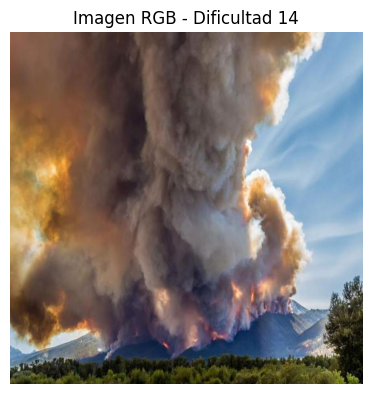

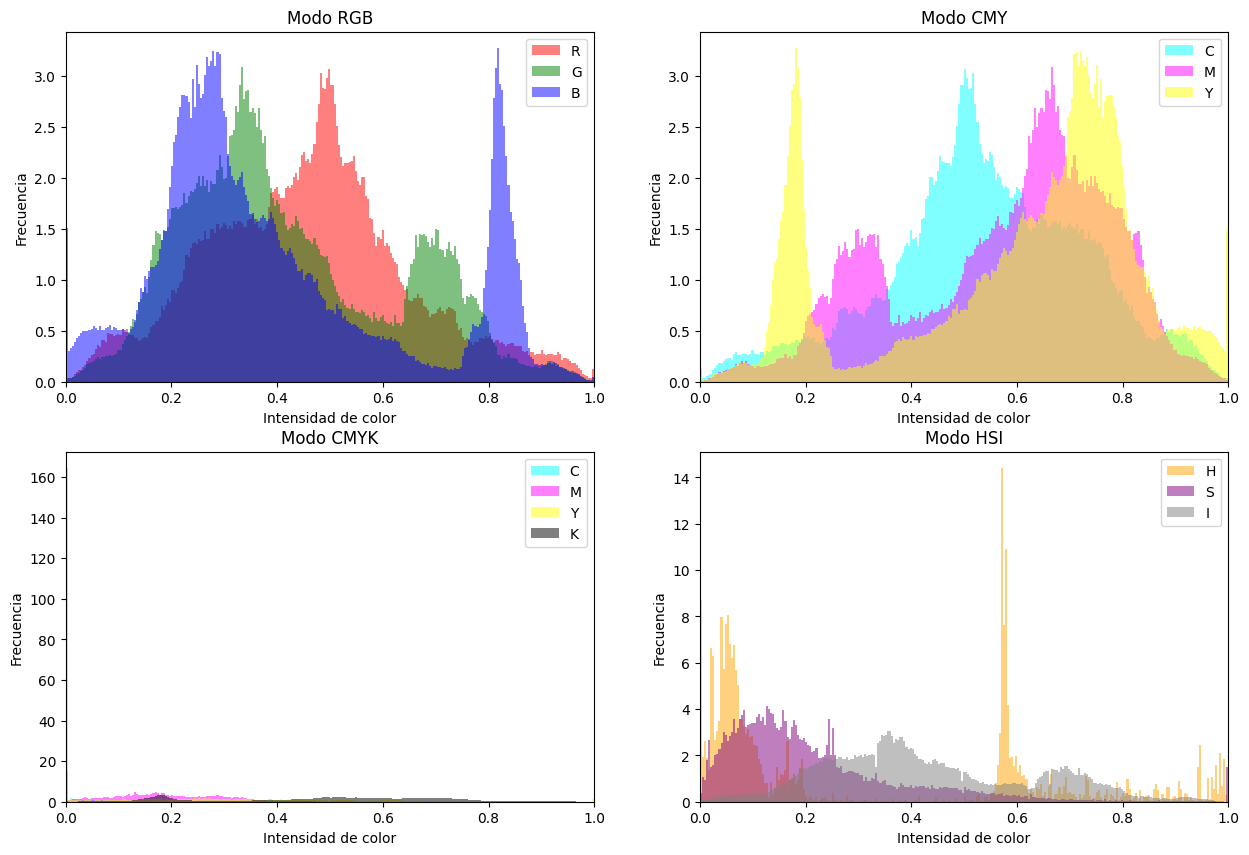

In [46]:
# Para la imagen 1 en todos los modos de color, mostrar la distribución de los histogramas de cada canal de color
img_num = 14

R, G, B = imagenes_rgb[img_num]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(np.stack((R, G, B), axis=-1))
plt.title(f"Imagen RGB - Dificultad {img_num}")
plt.axis('off')

channels_rgb = imagenes_rgb[img_num]
channels_cmy = imagenes_cmy[img_num]
channels_cmyk = imagenes_cmyk[img_num]
channels_hsi = imagenes_hsi[img_num]

print(f"Mostrando histogramas para la imagen con dificultad {img_num}")

# Generamos una figura con 4 subplots para mostrar los histogramas de cada modo de color
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
distribucion_histograma(channels_rgb, ["R", "G", "B"], tipo="RGB")
plt.title("Modo RGB")
plt.subplot(2, 2, 2)
distribucion_histograma(channels_cmy, ["C", "M", "Y"], tipo="CMY")
plt.title("Modo CMY")
plt.subplot(2, 2, 3)
distribucion_histograma(channels_cmyk, ["C", "M", "Y", "K"], tipo="CMYK")
plt.title("Modo CMYK")
plt.subplot(2, 2, 4)
distribucion_histograma(channels_hsi, ["H", "S", "I"], tipo="HSI")
plt.title("Modo HSI")
plt.show()

### Analisis para todas la imagenes en cada modo de color

In [53]:
def histograma_promedio_dict(dict_canales, idx_canal, bins=256):
    '''Promedia los histogramas de un canal específico sobre todas las imágenes
    del diccionario, conservando la forma de la distribución.

    Params:
        dict_canales : dict {id_imagen: tuple de canales (arrays 2D numpy)}
        idx_canal    : índice del canal dentro del tuple (0=primer canal, etc.)
        bins         : número de bins del histograma
    '''
    acumulado = np.zeros(bins)

    for canales in dict_canales.values():
        canal = canales[idx_canal].flatten().astype(float)
        if canal.max() > 1.0:
            canal = canal / canal.max()
        hist, _ = np.histogram(canal, bins=bins, range=(0, 1))
        acumulado += hist

    return acumulado / len(dict_canales)


def distribucion_histograma_promedio(dict_canales, names_channels,
                                     normalize=True, tipo="RGB", bins=256):
    '''Muestra en un solo gráfico la distribución promedio de cada canal
    calculada sobre todas las imágenes del diccionario.

    Params:
        dict_canales  : dict {id_imagen: tuple de canales}
        names_channels: lista de nombres de canales, ej. ["H", "S", "I"]
        normalize     : si True, normaliza el histograma como densidad
        tipo          : modo de color para asignar colores ("RGB","CMY","CMYK","HSI")
        bins          : número de bins
    '''
    colores_modo = {
        "RGB":  ['red', 'green', 'blue'],
        "CMY":  ['cyan', 'magenta', 'yellow'],
        "CMYK": ['cyan', 'magenta', 'yellow', 'black'],
        "HSI":  ['orange', 'purple', 'gray'],
    }
    colors = colores_modo.get(tipo, ['red', 'green', 'blue'])
    x = np.linspace(0, 1, bins)

    for i, name in enumerate(names_channels):
        hist_prom = histograma_promedio_dict(dict_canales, i, bins)
        if normalize:
            hist_prom = hist_prom / (hist_prom.sum() + 1e-8)
        plt.plot(x, hist_prom, alpha=0.7, label=name, color=colors[i])

    plt.xlabel("Intensidad de color")
    plt.ylabel("Frecuencia promedio")
    plt.legend(names_channels)
    plt.xlim([0, 1])
    return plt

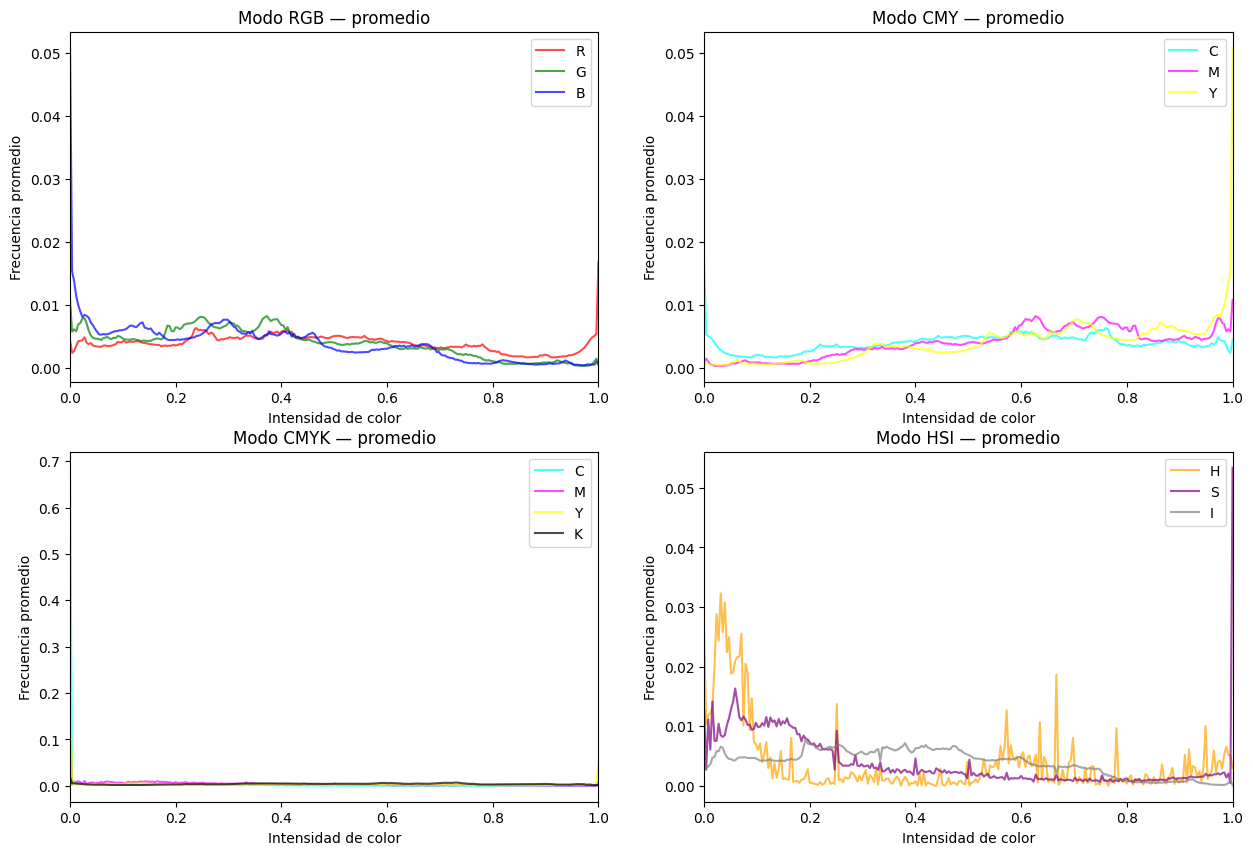

In [54]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
distribucion_histograma_promedio(imagenes_rgb, ["R", "G", "B"], tipo="RGB")
plt.title("Modo RGB — promedio")
plt.subplot(2, 2, 2)
distribucion_histograma_promedio(imagenes_cmy, ["C", "M", "Y"], tipo="CMY")
plt.title("Modo CMY — promedio")
plt.subplot(2, 2, 3)
distribucion_histograma_promedio(imagenes_cmyk, ["C", "M", "Y", "K"], tipo="CMYK")
plt.title("Modo CMYK — promedio")
plt.subplot(2, 2, 4)
distribucion_histograma_promedio(imagenes_hsi, ["H", "S", "I"], tipo="HSI")
plt.title("Modo HSI — promedio")
plt.show()